In [1]:
pip install pandas numpy matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


## Import Packages

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [9]:
df = pd.read_csv('DataCoSupplyChainDataset.csv',encoding = 'latin-1')

In [10]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Order Zipcode', 'Product Card Id', 'Product Category Id',
       'Product De

## EDA

In [12]:
#Summary
print('rows','cols',df.shape)
print('\ncolumns')
print(df.columns.tolist())
print('\n Duplicates Count:',df.duplicated().sum())
print('\n Missing Count (Top 10):')
print(df.isna().sum().sort_values(ascending = False).head(10))

rows cols (180519, 53)

columns
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Product S

In [13]:
#Data Cleaning
Columns_to_drop = ['Product Description',
                  'Product Image',
                  'Customer Email',
                  'Customer Password',
                  'Customer Fname',
                  'Customer Lname',
                  'Customer Street',
                  'Customer Zipcode',
                  'Order Zipcode',
                  'Longitude',
                  'Latitude',
                  'Order Item Cardprod Id',
                  'Order Item Id',
                  'Order Item Discount',
                  'Order Item Discount Rate',
                  'Order Item Product Price',
                  'Order Item Quantity',
                  'Order Item Total',
                  'Category Id',
                  'Department Id',
                  'Order Id',
                  'Order Customer Id',
                  'Customer Id',
                  'Product Card Id',
                  'Product Category Id',
                  'Benefit per order',
                  'Product Status',
                  'Customer City',
                  'Order City',
                  'Order Country',
                  'Order State',
                  'Customer State',
                  'Market']

#Dropping columns which are redundant,fully missing or have only one Value
df = df.drop(columns=Columns_to_drop)

#removing cancelled orders as they are irrelevant for delivery time anlysis as they may differ patterns from completed orders
df = df[df['Delivery Status'] != 'Shipping canceled']

# standard Date conversion
for c in ['order date (DateOrders)','shipping date (DateOrders)']:
    df[c] = pd.to_datetime(df[c],errors = 'coerce',dayfirst=False)

#after cleaning the data, let's check summary again
print('rows','cols',df.shape)
print('\n Missing Count (Top 5):')
print(df.isna().sum().sort_values(ascending = False).head(5))

rows cols (172765, 20)

 Missing Count (Top 5):
Type                             0
Days for shipping (real)         0
Days for shipment (scheduled)    0
Sales per customer               0
Delivery Status                  0
dtype: int64


In [12]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Customer Country,Customer Segment,Department Name,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Order Region,Order Status,Product Name,Product Price,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,314.640015,Advance shipping,0,Sporting Goods,Puerto Rico,Consumer,Fitness,2018-01-31 22:56:00,0.29,327.75,91.250000,Southeast Asia,COMPLETE,Smart watch,327.75,2018-02-03 22:56:00,Standard Class
1,TRANSFER,5,4,311.359985,Late delivery,1,Sporting Goods,Puerto Rico,Consumer,Fitness,2018-01-13 12:27:00,-0.80,327.75,-249.089996,South Asia,PENDING,Smart watch,327.75,2018-01-18 12:27:00,Standard Class
2,CASH,4,4,309.720001,Shipping on time,0,Sporting Goods,EE. UU.,Consumer,Fitness,2018-01-13 12:06:00,-0.80,327.75,-247.779999,South Asia,CLOSED,Smart watch,327.75,2018-01-17 12:06:00,Standard Class
3,DEBIT,3,4,304.809998,Advance shipping,0,Sporting Goods,EE. UU.,Home Office,Fitness,2018-01-13 11:45:00,0.08,327.75,22.860001,Oceania,COMPLETE,Smart watch,327.75,2018-01-16 11:45:00,Standard Class
4,PAYMENT,2,4,298.250000,Advance shipping,0,Sporting Goods,Puerto Rico,Corporate,Fitness,2018-01-13 11:24:00,0.45,327.75,134.210007,Oceania,PENDING_PAYMENT,Smart watch,327.75,2018-01-15 11:24:00,Standard Class


In [14]:
# value columns for categorial columns with low cardinality
for col in df.columns:
    if df[col].nunique() <10:
        print(f'\n{col} value counts:')
        print(df[col].value_counts())

    


Type value counts:
Type
DEBIT       69295
TRANSFER    42129
PAYMENT     41725
CASH        19616
Name: count, dtype: int64

Days for shipping (real) value counts:
Days for shipping (real)
2    54205
6    27489
3    27478
4    27297
5    27003
0     4839
1     4454
Name: count, dtype: int64

Days for shipment (scheduled) value counts:
Days for shipment (scheduled)
4    103153
2     33806
1     26513
0      9293
Name: count, dtype: int64

Delivery Status value counts:
Delivery Status
Late delivery       98977
Advance shipping    41592
Shipping on time    32196
Name: count, dtype: int64

Late_delivery_risk value counts:
Late_delivery_risk
1    98977
0    73788
Name: count, dtype: int64

Customer Country value counts:
Customer Country
EE. UU.        106425
Puerto Rico     66340
Name: count, dtype: int64

Customer Segment value counts:
Customer Segment
Consumer       89420
Corporate      52528
Home Office    30817
Name: count, dtype: int64

Order Status value counts:
Order Status
COMPLETE  

In [15]:
#Calculating order processing time & delay
df['Order Processing Time'] = (df['shipping date (DateOrders)']-df['order date (DateOrders)']).dt.days
df['Delay'] = df['Order Processing Time']-df['Days for shipment (scheduled)']
df['Is_Delayed'] = df['Delay'] > 0
df['order_month'] = df['order date (DateOrders)'].dt.month
df['order_day'] = df['order date (DateOrders)'].dt.day_name()
df['order_hour'] = df['order date (DateOrders)'].dt.hour
df.describe()

,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Late_delivery_risk,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Product Price,shipping date (DateOrders),Order Processing Time,Delay,order_month,order_hour
count,172765.000000,172765.000000,172765.000000,172765.000000,172765,172765.000000,172765.000000,172765.000000,172765.000000,172765,172765.000000,172765.000000,172765.000000,172765.000000
mean,3.498596,2.933100,183.165948,0.572900,2016-06-12 15:25:39.457991,0.120801,203.828493,22.032360,141.278595,2016-06-16 03:25:14.452927,3.472816,0.539716,6.235511,11.482604
min,0.000000,0.000000,7.490000,0.000000,2015-01-01 00:00:00,-2.750000,9.990000,-4274.979980,9.990000,2015-01-03 00:00:00,0.000000,-2.000000,1.000000,0.000000
25%,2.000000,2.000000,104.379997,0.000000,2015-09-21 18:01:00,0.080000,119.980003,7.030000,50.000000,2015-09-25 08:59:00,2.000000,0.000000,3.000000,5.000000
50%,3.000000,4.000000,163.990005,1.000000,2016-06-11 08:11:00,0.270000,199.919998,31.520000,59.990002,2016-06-15 03:38:00,3.000000,1.000000,6.000000,11.000000
75%,5.000000,4.000000,247.399994,1.000000,2017-02-28 21:08:00,0.360000,299.950012,64.800003,199.990005,2017-03-04 08:00:00,5.000000,1.000000,9.000000,17.000000
max,6.000000,4.000000,1939.989990,1.000000,2018-01-31 23:38:00,0.500000,1999.989990,911.799988,1999.989990,2018-02-06 22:14:00,6.000000,4.000000,12.000000,23.000000
std,1.623446,1.373405,120.141871,0.494659,NaN,0.466610,132.392520,104.355313,139.862956,NaN,1.670187,1.494150,3.405593,6.927276


In [16]:
df['Is_Delayed'].value_counts()


Is_Delayed
True     94523
False    78242
Name: count, dtype: int64

In [17]:
df.columns


Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Sales per customer', 'Delivery Status', 'Late_delivery_risk',
       'Category Name', 'Customer Country', 'Customer Segment',
       'Department Name', 'order date (DateOrders)', 'Order Item Profit Ratio',
       'Sales', 'Order Profit Per Order', 'Order Region', 'Order Status',
       'Product Name', 'Product Price', 'shipping date (DateOrders)',
       'Shipping Mode', 'Order Processing Time', 'Delay', 'Is_Delayed',
       'order_month', 'order_day', 'order_hour'],
      dtype='str')

In [19]:
#profitability based Profit per order
df['Profitability Flag'] = np.where(df['Order Profit Per Order'] > 0,'Profit',np.where(df['Order Profit Per Order'] < 0,'Loss','Break-even'))
df['Profitability Flag'].value_counts()

Profitability Flag
Profit        139354
Loss           32295
Break-even      1116
Name: count, dtype: int64

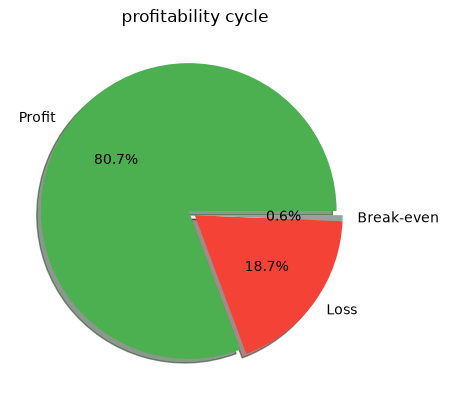

In [20]:
#visulization of Profit 
profit_counts = df['Profitability Flag'].value_counts(normalize = True)*100
profit_counts.plot(kind = 'pie', autopct = '%1.1f%%',explode=(0.05,0,0),shadow=True,colors = ['#4CAF50', '#F44336', '#9E9E9E'])
plt.ylabel('')
plt.title('profitability cycle')
plt.show()

## Metrics Calculations

In [22]:
def format_func(val):
    if val >= 1e6:
        return f'{val/1e6: .1f}M $'
    elif val >= 1e3:
        return f'{val/1e3: .1f}K $'
    else:
        return f'{val: .0f} $'
        
delayed_df = df[df['Delay'] > 0]
metrics = {}
metrics['Total Orders'] = len(df)
metrics['Late Deliveries'] = len(delayed_df)
metrics['90% Delay (Days)'] = delayed_df['Delay'].quantile(0.90)
metrics['on time Delivery %'] = (1 - float(metrics['Late Deliveries'])/ metrics['Total Orders'])* 100
metrics['Late Delevery %'] = float(metrics['Late Deliveries'])/metrics['Total Orders']* 100
metrics['Total Profit'] = format_func(df.loc[df['Order Profit Per Order'] > 0,'Order Profit Per Order'].sum())
metrics['Total Loss due to delay'] = format_func(df.loc[df['Delay'] > 0,'Order Profit Per Order'].sum())

print('\n --- Business KPIs ---\n')
for k, v in metrics.items():
    if isinstance(v, float):
        print(f"{k}: {v: .2f}")
    else:
        print(f"{k}:{v}")


 --- Business KPIs ---

Total Orders:172765
Late Deliveries:94523
90% Delay (Days):  3.00
on time Delivery %:  45.29
Late Delevery %:  54.71
Total Profit: 7.5M $
Total Loss due to delay: 2.1M $


In [23]:
profit_metrics = (
    df.groupby('Delay')['Order Profit Per Order'].agg(
        mean_profit = 'mean',
        total_profit = 'sum',
        order_count = 'count'
    ).reset_index())

In [35]:
profit_metrics


,Delay,mean_profit,total_profit,order_count
0,-2,23.360134,4.875961e+05,20873
1,-1,21.604769,4.476292e+05,20719
2,0,22.249118,8.154302e+05,36650
3,1,22.333227,1.194895e+06,53503
4,2,21.128491,5.821110e+05,27551
5,3,20.031412,1.356527e+05,6772
6,4,21.368783,1.431067e+05,6697


In [24]:
delay_distribution = (df['Delay'].value_counts(normalize = True).sort_index()*100).reset_index()

In [38]:
delay_distribution

,Delay,proportion
0,-2,12.081730
1,-1,11.992591
2,0,21.213788
3,1,30.968657
4,2,15.947096
5,3,3.919775
6,4,3.876364


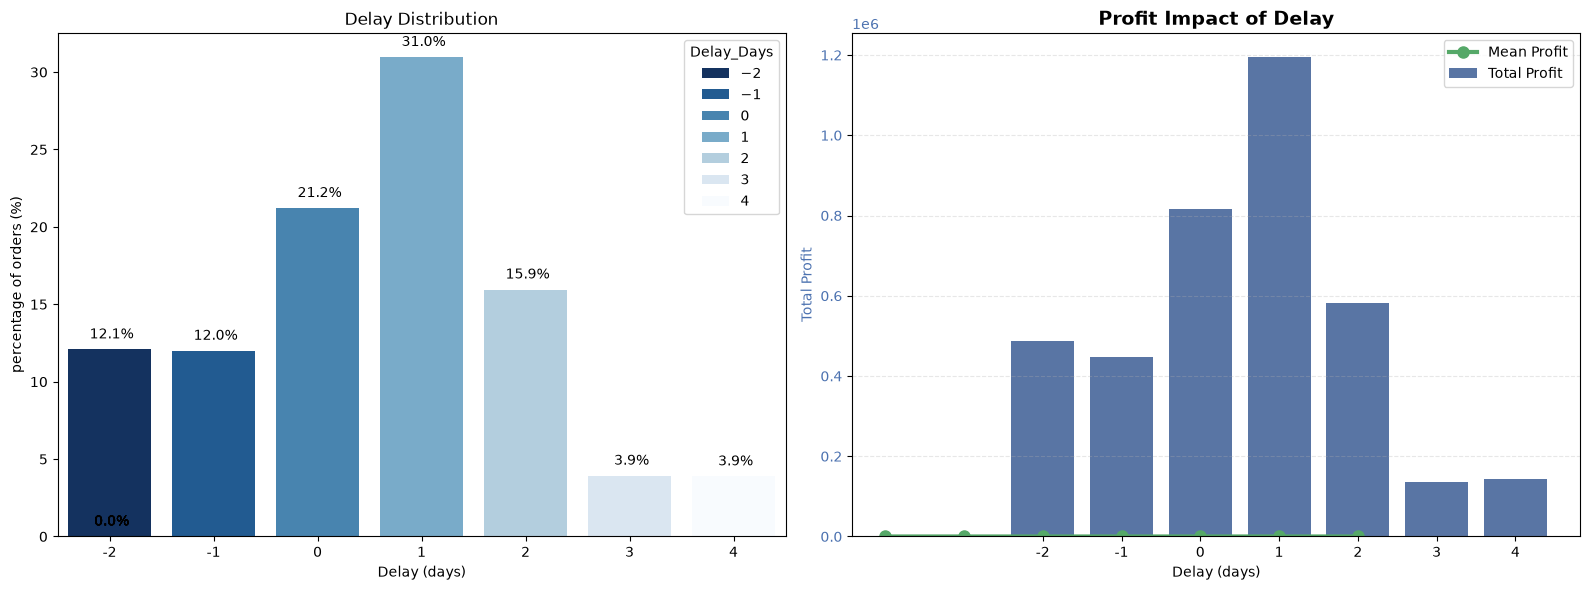

In [28]:
delay_distribution.columns = ['Delay_Days','Percentage']

fig, (ax1, ax2) = plt.subplots(1,2, figsize = (16, 6))

# first subplot
sns.barplot(x='Delay_Days',y='Percentage', data = delay_distribution, ax = ax1,hue='Delay_Days',palette='Blues_r')
ax1.set_title('Delay Distribution')
ax1.set_xlabel('Delay (days)')
ax1.set_ylabel('percentage of orders (%)')

#pct on bars
for bar in ax1.patches:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2,height + 0.5,f'{height: .1f}%', ha='center',va='bottom')


# Second plot
sns.barplot(
    x='Delay',
    y='total_profit',
    data=profit_metrics,
    ax=ax2,
    color='#4C72B0',
    label='Total Profit'
)

ax2.set_title('Profit Impact of Delay', fontsize=14, fontweight='bold')
ax2.set_xlabel('Delay (days)')
ax2.set_ylabel('Total Profit', color='#4C72B0')

ax2.tick_params(axis='y', labelcolor='#4C72B0')


# Mean Profit
ax2.plot(
    profit_metrics['Delay'],
    profit_metrics['mean_profit'],
    color='#55A868',
    marker='o',
    linewidth=3,
    markersize=8,
    label='Mean Profit'
)

ax2.legend()

ax2.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()